In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp
tfb = tfp.bijectors
tfd = tfp.distributions

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma, gammaincc

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import json
import gc
import glob
from pathlib import Path

import thetaflow as thf


import gg
sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1780441497.966195 1071302 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780441498.008772 1071302 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780441499.184538 1071302 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780441500.131373 1071302 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

94 features
90000 colunas - Treino
30000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

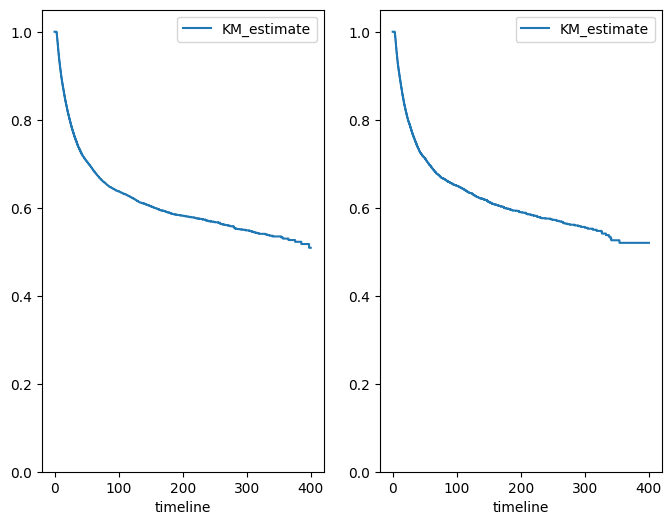

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

In [5]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

# Generalized Gamma Model

### Without covariates

In [6]:
def build_gg_model():

    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)
    
    # parameters = {
    #     # Generalized Gamma components (Y = X^power, where X ~ Gamma(concentration, rate))
    #     "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
    #     "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
    #     "c": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 0.5, "warmup_time": 0}
    # }

    parameters = {
        # Generalized Gamma components (Y = X^power, where X ~ Gamma(concentration, rate))
        "alpha": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "beta": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "c": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "independent", "shape": 1, "init": 0.5, "warmup_time": 0}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps
        
        alpha = model.get_variable("alpha")
        beta = model.get_variable("beta")
        c = model.get_variable("c")

        # Ensure constant parameters will have the same shape as y_safe for calculations inside the gg functions
        alpha = tf.broadcast_to(alpha, tf.shape(y_safe))
        beta = tf.broadcast_to(beta, tf.shape(y_safe))
        c = tf.broadcast_to(c, tf.shape(y_safe))
        
        log_f = gg.log_pdf(y_safe, alpha, c, beta)
        log_S = gg.log_S(y_safe, alpha, c, beta)

        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    return parameters, loglikelihood_loss, None, None, None

In [7]:
with tf.device("/GPU:0"):
    gg_parameters, gg_loss, gg_neural_network, gg_call, gg_call_nolast = \
    build_gg_model( )
    seed = 10
    gg_model = thf.ModelNN(gg_parameters, gg_loss,
                           gg_neural_network, gg_call,
                           gg_call_nolast, input_dim = (1,), seed = seed)
    gg_model.train_model(epochs = 1200, x = None, data = data_train,
                         shuffle = True,
                         get_covariances = False,
                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                         force_training_validation = False,
                         optimizer_independent = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                         optimizer_nn = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                         fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                         early_stopping = True, early_stopping_patience = 30,
                         early_stopping_warmup = 10,
                         reduce_lr = True, reduce_lr_warmup = 0,
                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 500, reduce_lr_patience = 25,
                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                         fine_tune = True,
                         finetune_early_stopping = True, finetune_early_stopping_patience = 30,
                         finetune_early_stopping_warmup = 10,
                         finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                         finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 5, finetune_reduce_lr_patience = 25,
                         finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                         deterministic = True,
                         verbose = True, print_freq = 1,
                         train_batch_size = None, val_batch_size = None,
                         buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 130 / 1200 ]  | Loss:  15115.9043 | Best Loss:  15335.6211 | Speed:  33  epoch/s    | Elapsed Time:  3.8391552  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 6.786 seconds.


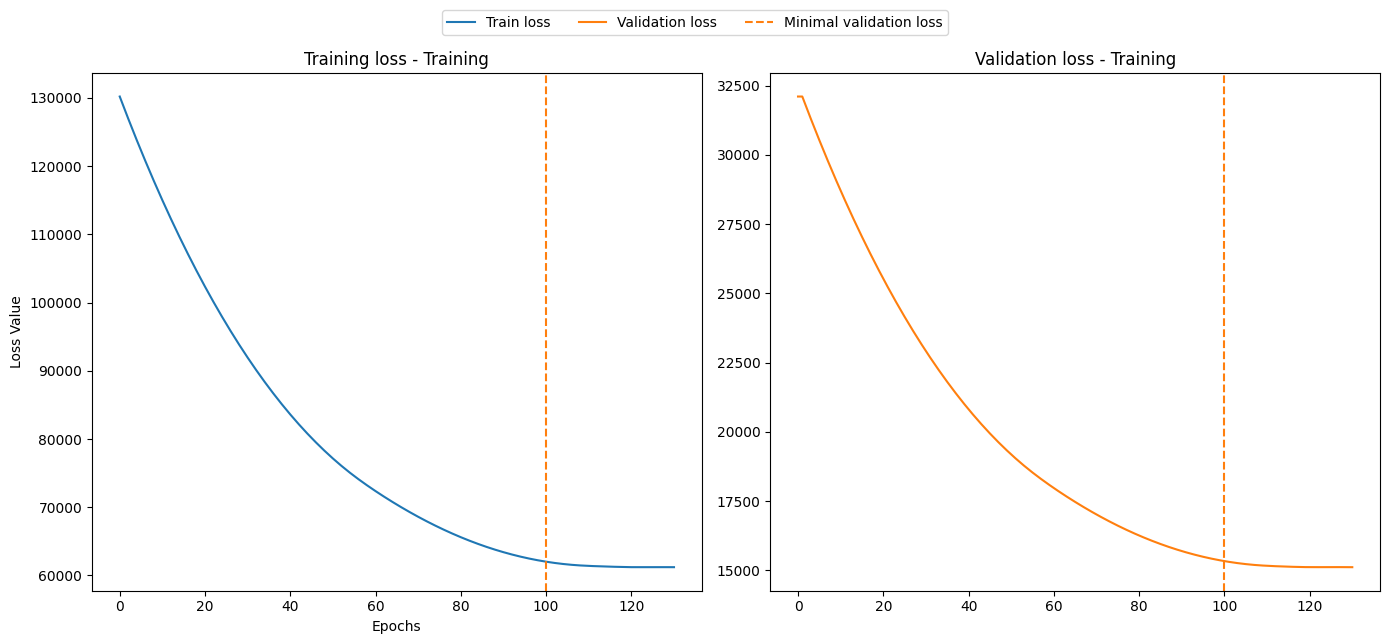

In [8]:
utils.plot_model_convergence( gg_model )

In [9]:
alpha = gg_model.predict("alpha")
beta = gg_model.predict("beta")
c = gg_model.predict("c")
print("alpha:", alpha)
print("beta:", beta)
print("c:", c)

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

S_ts_train = gg.S(ts_grid, alpha, c, beta)
S_ts_test = gg.S(ts_grid, alpha, c, beta)

S_train = gg.S(y_train, alpha, c, beta)
S_test = gg.S(y_test, alpha, c, beta)
H_train = -np.log( S_train )
H_test = -np.log( S_test )

alpha: [1.7435657]
beta: [0.4860217]
c: [0.3962918]


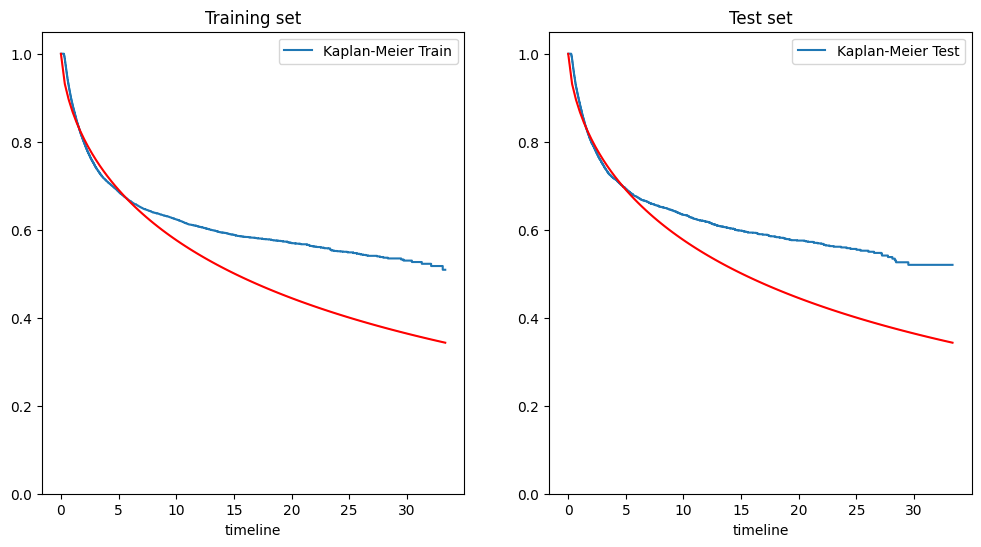

In [10]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

### With all covariates

In [11]:
def build_gg_model_full():

    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)
    
    # parameters = {
    #     # Generalized Gamma components (Y = X^power, where X ~ Gamma(concentration, rate))
    #     "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
    #     "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
    #     "c": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 0.5, "warmup_time": 0}
    # }

    parameters = {
        # Generalized Gamma components (Y = X^power, where X ~ Gamma(concentration, rate))
        "alpha": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
        "beta": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
        "c": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": 0.5, "warmup_time": 0}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps
        
        alpha = model.get_variable("alpha", nn_output)
        beta = model.get_variable("beta", nn_output)
        c = model.get_variable("c", nn_output)

        # Ensure constant parameters will have the same shape as y_safe for calculations inside the gg functions
        alpha = tf.broadcast_to(alpha, tf.shape(y_safe))
        beta = tf.broadcast_to(beta, tf.shape(y_safe))
        c = tf.broadcast_to(c, tf.shape(y_safe))
        
        log_f = gg.log_pdf(y_safe, alpha, c, beta)
        log_S = gg.log_S(y_safe, alpha, c, beta)

        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    def neural_network(model, seed = None):
        initializer = tf.keras.initializers.GlorotNormal(seed=seed)

        elastic_net = tf.keras.regularizers.L1L2(l1 = 0.05, l2 = 0.05)

        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer,
            kernel_regularizer = elastic_net,
            name = "tabular_features_extractor"
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_1"
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.output_layer = layers.Dense(
            units = 3,
            activation = None, # Linear, o exponente fica na Loss function
            kernel_initializer = initializer,
            name = "log_lambda_output"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [12]:
with tf.device("/GPU:0"):
    gg_parameters, gg_loss, gg_neural_network, gg_call, gg_call_nolast = \
    build_gg_model_full( )
    seed = 10
    gg_model_full = thf.ModelNN(gg_parameters, gg_loss,
                           gg_neural_network, gg_call,
                           gg_call_nolast, input_dim = (X_train.shape[1],), seed = seed)
    gg_model_full.pre_train_model(epochs = None, x = X_train, data = data_train, shuffle = True)
    gg_model_full.train_model(epochs = 2500, x = X_train, data = data_train,
                         shuffle = True,
                         get_covariances = False,
                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                         force_training_validation = False,
                         optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                         optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                         fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                         early_stopping = True, early_stopping_patience = 30,
                         early_stopping_warmup = 10,
                         reduce_lr = True, reduce_lr_warmup = 0,
                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 500, reduce_lr_patience = 25,
                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                         fine_tune = True,
                         finetune_early_stopping = True, finetune_early_stopping_patience = 30,
                         finetune_early_stopping_warmup = 10,
                         finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                         finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 5, finetune_reduce_lr_patience = 25,
                         finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                         deterministic = True,
                         verbose = True, print_freq = 1,
                         train_batch_size = None, val_batch_size = None,
                         buffer_size = None, gradient_accumulation_steps = None)

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'model_nn_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 126 / 2500 ]  | Loss:  13118.1904 | Best Loss:  13611.9912 | Speed:  38  epoch/s    | Elapsed Time:  3.24333978  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 1090 / 2500 ]  | Loss:  53359.9062 | Best Loss:  53364.8047 | Speed:  63  epoch/s    | Elapsed Time:  17.1629162  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 22.906 seconds.


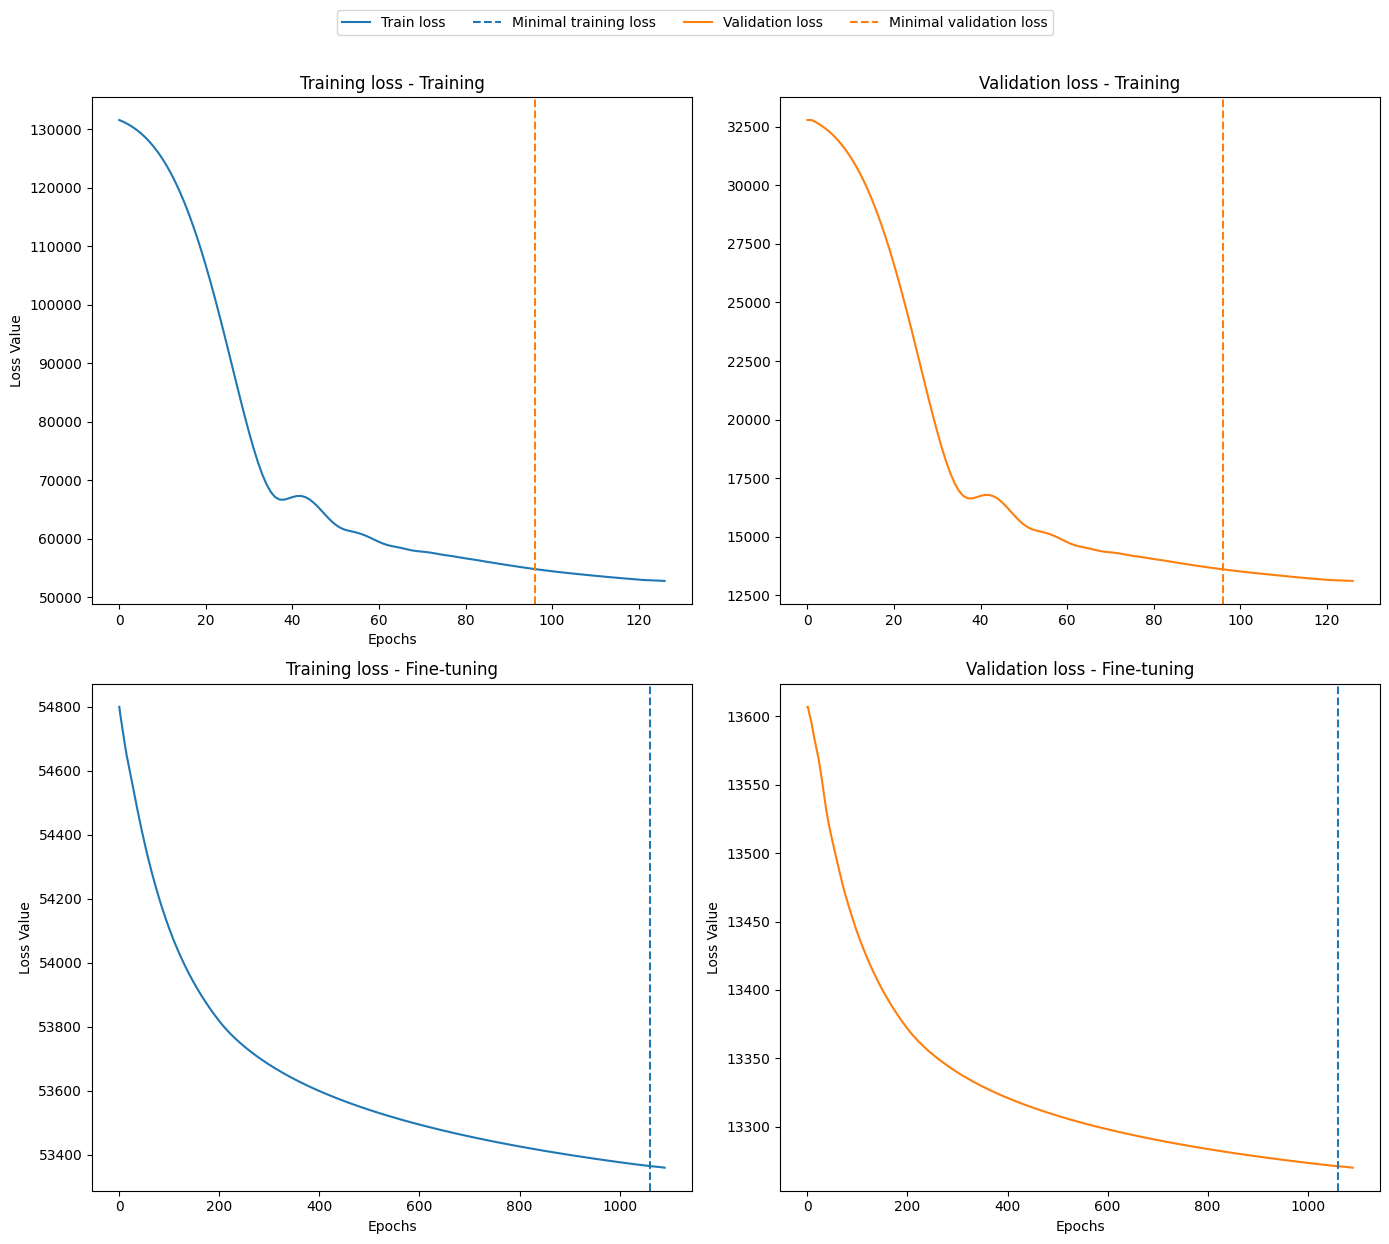

In [13]:
utils.plot_model_convergence( gg_model_full )

In [14]:
pars_train = gg_model_full.predict(X_train)
pars_test = gg_model_full.predict(X_test)

alpha_train = pars_train["alpha"].numpy().flatten()
beta_train = pars_train["beta"].numpy().flatten()
c_train = pars_train["c"].numpy().flatten()

alpha_test = pars_test["alpha"].numpy().flatten()
beta_test = pars_test["beta"].numpy().flatten()
c_test = pars_test["c"].numpy().flatten()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

S_ts_train_full = gg.S(ts_grid, alpha_train, c_train, beta_train).numpy()
S_ts_test_full = gg.S(ts_grid, alpha_test, c_test, beta_test).numpy()

S_train_full = gg.S(y_train, alpha_train, c_train, beta_train).numpy()
S_test_full = gg.S(y_test, alpha_test, c_test, beta_test).numpy()
H_train_full = -np.log( S_train )
H_test_full = -np.log( S_test )

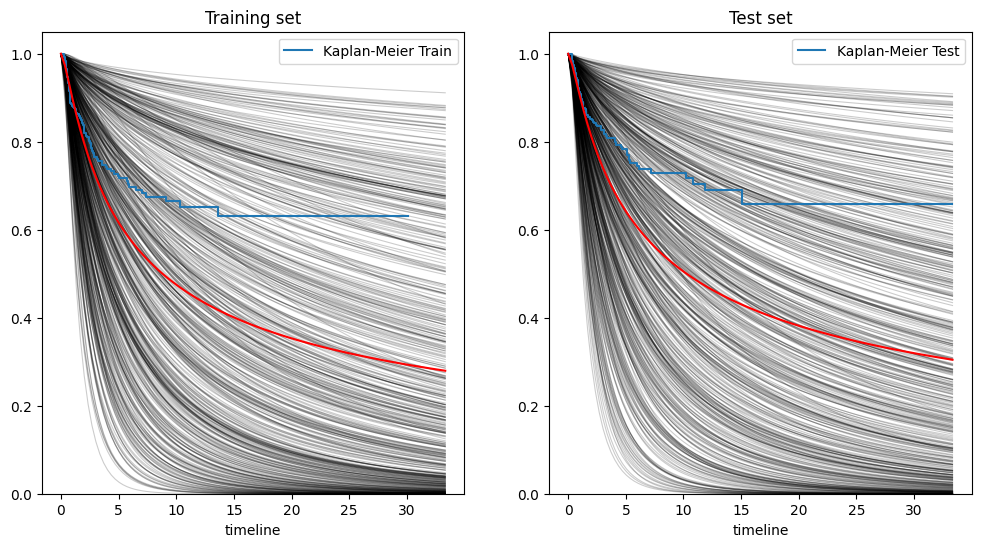

In [15]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

n_max = 500
# n_max = S_ts_train_full.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_full.shape[1]), size = n_max )
test_idx = np.random.choice( np.arange(S_ts_test_full.shape[1]), size = n_max )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_full[:, train_idx], S_ts_test_full[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()